In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="jyr0hJYNK8EbOiN20vOR")
project = rf.workspace("marblerace").project("skin-diseases-ewn74")
version = project.version(2)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...


In [2]:
import os, shutil, random

root = "/content/skin-diseases-2"
train_classes = set(os.listdir(f"{root}/train"))

for split in ["valid", "test"]:
    split_classes = set(os.listdir(f"{root}/{split}"))
    missing = train_classes - split_classes
    for cls in missing:
        src = f"{root}/train/{cls}"
        dst = f"{root}/{split}/{cls}"
        os.makedirs(dst, exist_ok=True)
        imgs = os.listdir(src)
        # move a small sample (e.g. 10%) instead of duplicating everything
        sample = random.sample(imgs, max(1, len(imgs)//10))
        for img in sample:
            shutil.move(f"{src}/{img}", f"{dst}/{img}")
    print(f"{split}: filled in {missing}")

valid: filled in {'Basal Cell Carcinoma', 'Dermatofibroma'}
test: filled in {'Nevus', 'Basal Cell Carcinoma', 'Dermatofibroma', 'Melanoma', 'Pigmented Benign Keratosis', 'Acitinic Keratosis'}


In [3]:
!pip install ultralytics -q
from ultralytics import YOLO

model_cls = YOLO("yolov8m-cls.pt")

results_cls = model_cls.train(
    data=dataset.location,   # points to your skin-disease folder-format download
    epochs=50,
    imgsz=224,
    name = "skin classification"
)

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/skin-diseases-2, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=skin classification-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

In [4]:
metrics_cls = model_cls.val(
    data=dataset.location,   # same folder used for training
    split="test"
)

test_accuracy = metrics_cls.top1
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,774,185 parameters, 0 gradients, 41.6 GFLOPs
train: /content/skin-diseases-2/train... found 2921 images in 9 classes ✅ 
val: /content/skin-diseases-2/valid... found 833 images in 9 classes ✅ 
test: /content/skin-diseases-2/test... found 330 images in 9 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 735.5±312.3 MB/s, size: 25.6 KB)
test: Scanning /content/skin-diseases-2/test... 330 images, 0 corrupt: 100% ━━━━━━━━━━━━ 330/330 1.5Kit/s 0.2s
test: New cache created: /content/skin-diseases-2/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 21/21 4.0it/s 5.3s
                   all      0.739      0.991
Speed: 0.3ms preprocess, 4.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
Test Accuracy: 73.94%


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# ---------------------------
# 1. Ultralytics tells you exactly where results were saved
# ---------------------------
save_dir = results_cls.save_dir   # e.g. runs/classify/skin_classification
print(f"Results saved to: {save_dir}")

Results saved to: /content/runs/classify/skin classification-2


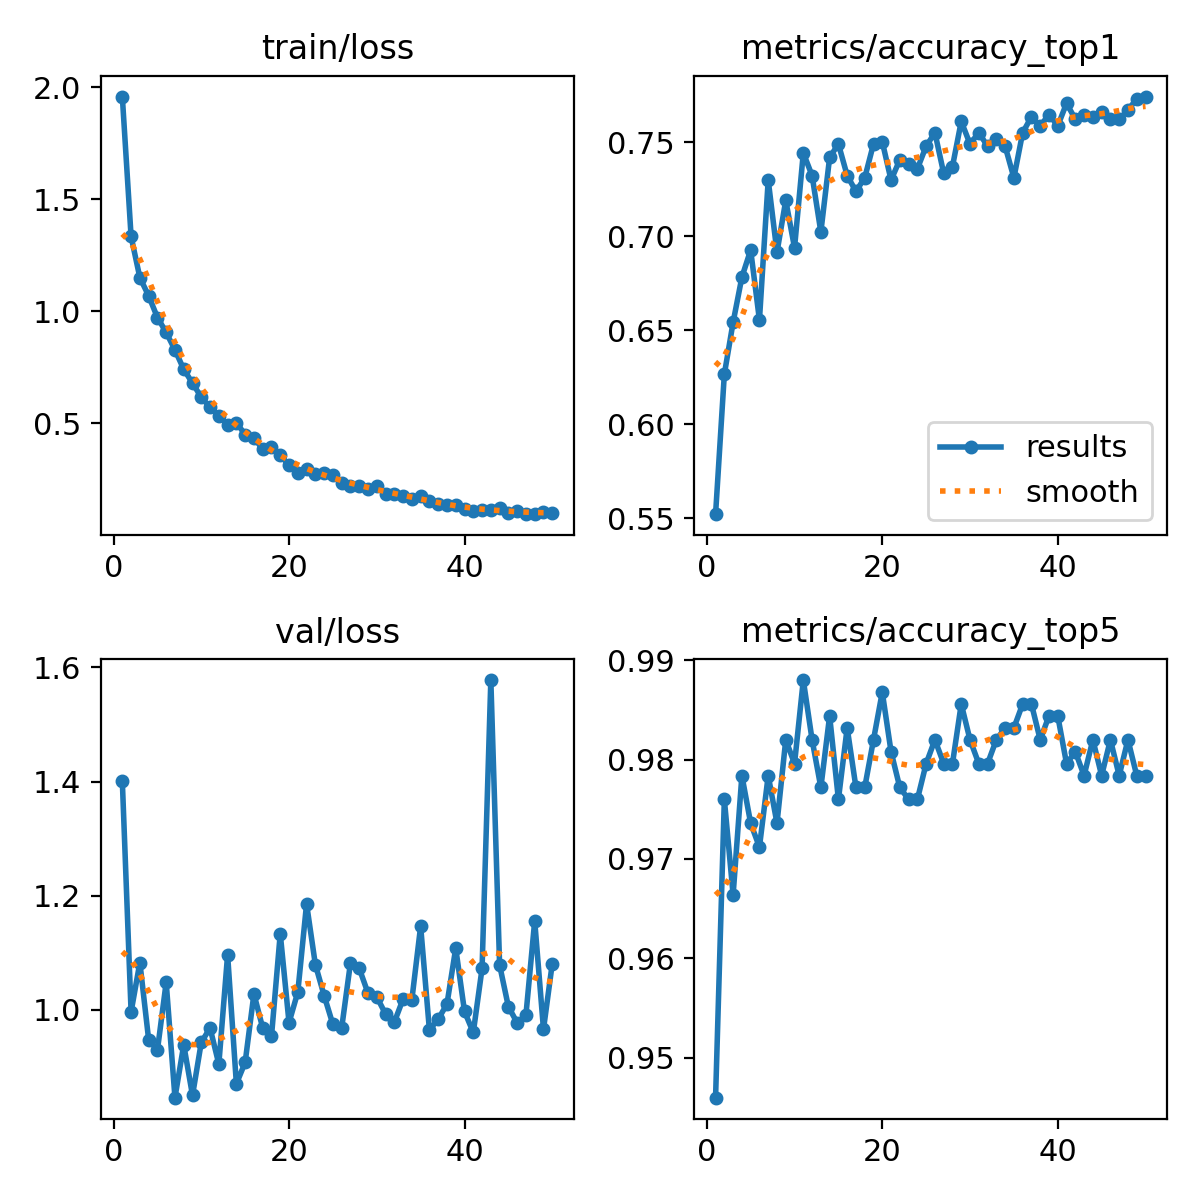

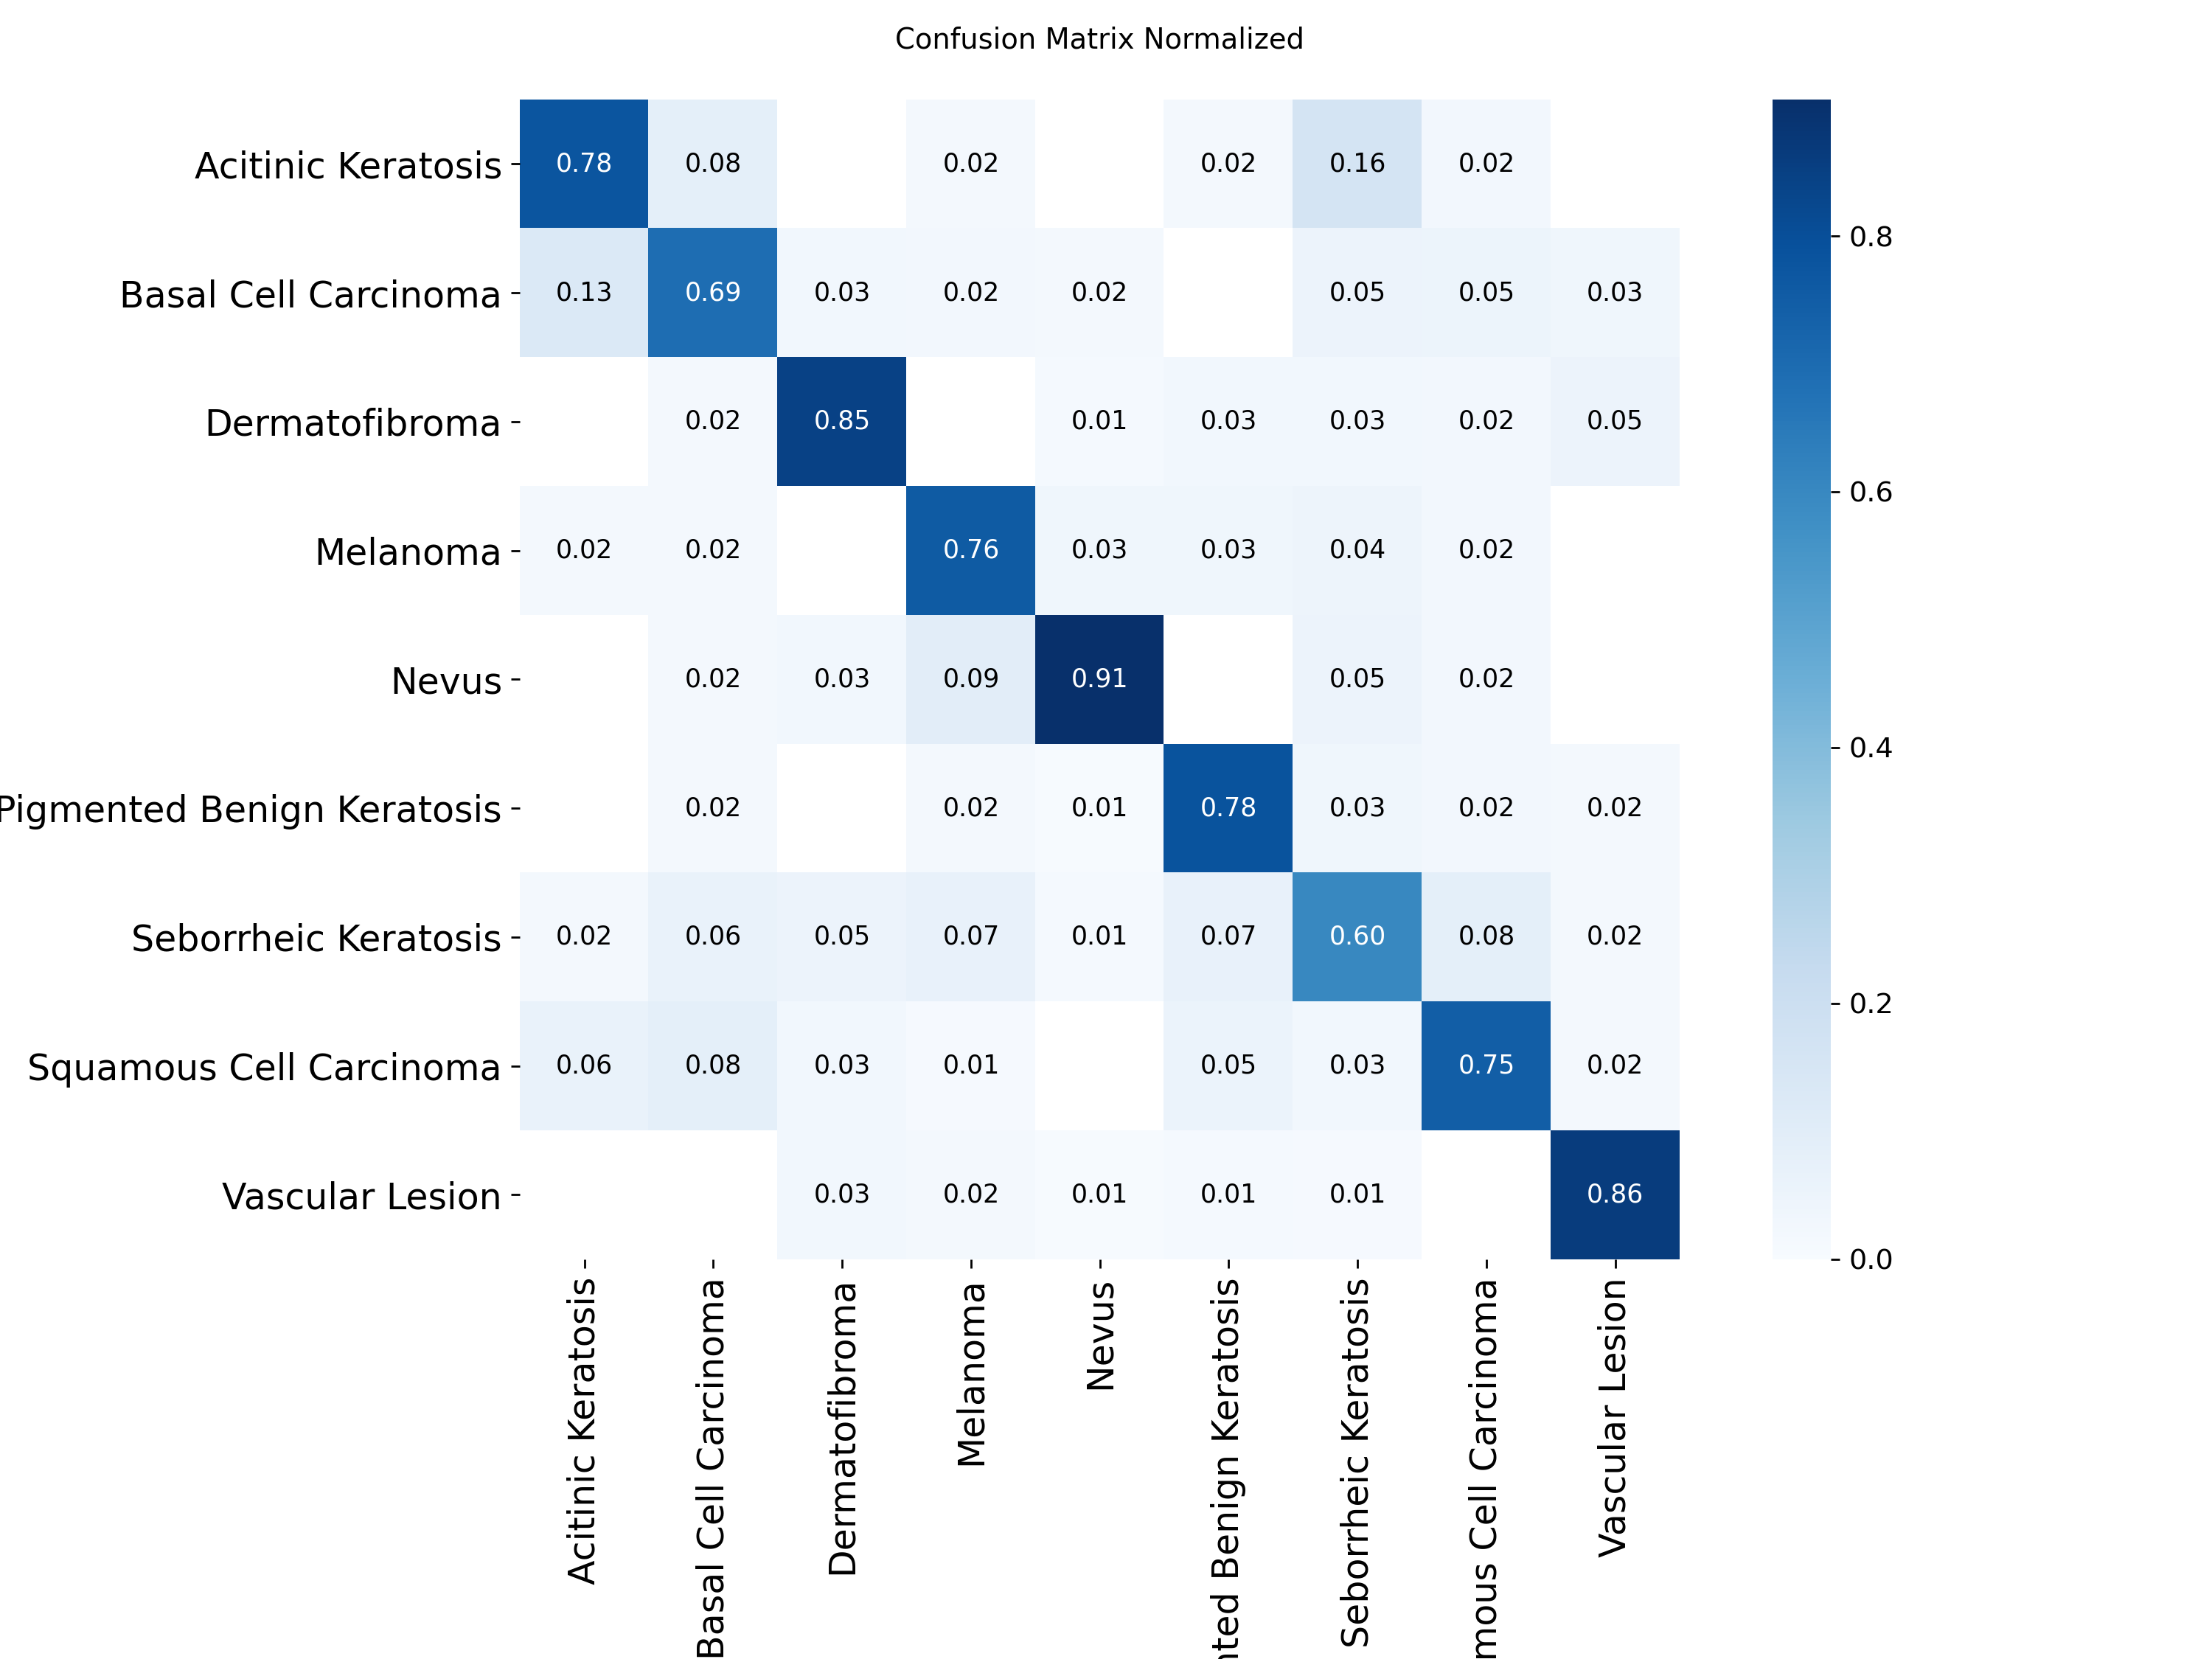

In [7]:
display(Image(f"{save_dir}/results.png"))
display(Image(f"{save_dir}/confusion_matrix_normalized.png"))
